In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from data_pipeline import cleaning_data

In [2]:
df=pd.read_csv(r"C:\Users\LOQ\Downloads\Exercise\ADY\house-prices-advanced-regression-techniques\train.csv")
target_name='SalePrice'
drop_threshold=0.6

In [3]:
X,y=cleaning_data(df,target_name=target_name,drop_threshold=drop_threshold)

In [4]:
y=np.expm1(y)
data=pd.concat((X,y),axis=1)

## **The Distribution of SalePrice**

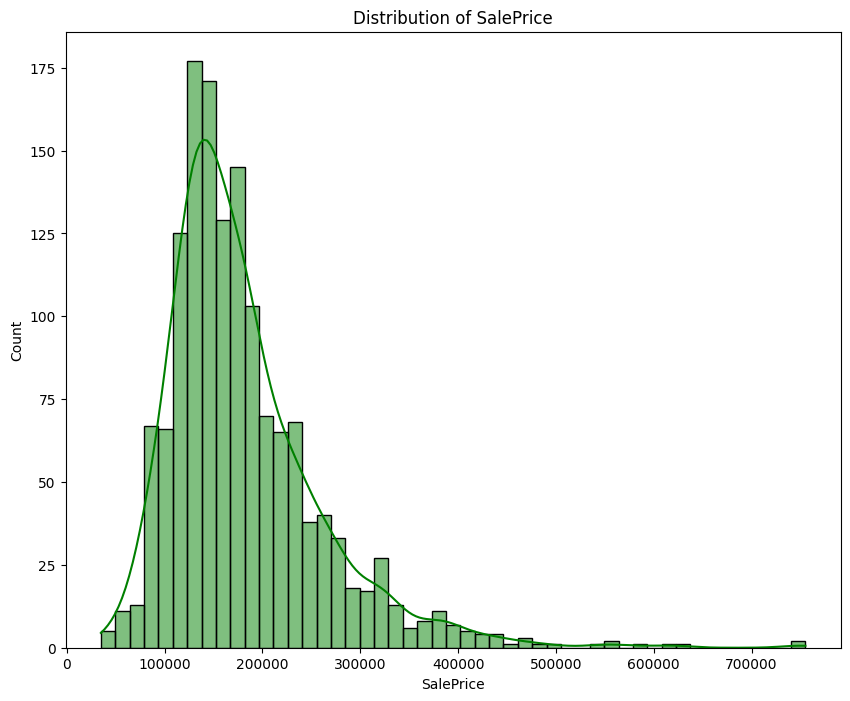

In [14]:
plt.figure(figsize=(10,8))
sns.histplot(data[target_name],kde=True,color='green')
plt.title('Distribution of SalePrice')
plt.show()

## **Top 10 features of Correlation Matrix**

Quality and Size are the Primary Drivers: OverallQual (0.79) and GrLivArea (0.71) exhibit the highest positive correlations with SalePrice. This indicates that the structural quality/finish and the total above-grade living area are the most critical factors determining a property's market value.

Utility and Foundation Add Significant Value: GarageCars (0.64) and TotalBsmtSF (0.64) also show strong positive correlations. Buyers clearly place a high premium on vehicle capacity and total basement square footage.

Age is Secondary to Space: Variables like YearBuilt (0.52) and YearRemodAdd (0.51) have a moderate impact. While newer or recently remodeled homes command higher prices, these factors are notably less influential than the pure size or overall quality of the house.

Notable Multicollinearity (Feature Interdependency): There are moderate correlations among the independent variables themselves, such as between OverallQual and GarageCars (0.61), or YearBuilt and YearRemodAdd (0.59). This logically suggests that newer homes tend to have better overall quality and larger garages, which is a structural characteristic of the dataset to keep in mind for regression modeling.

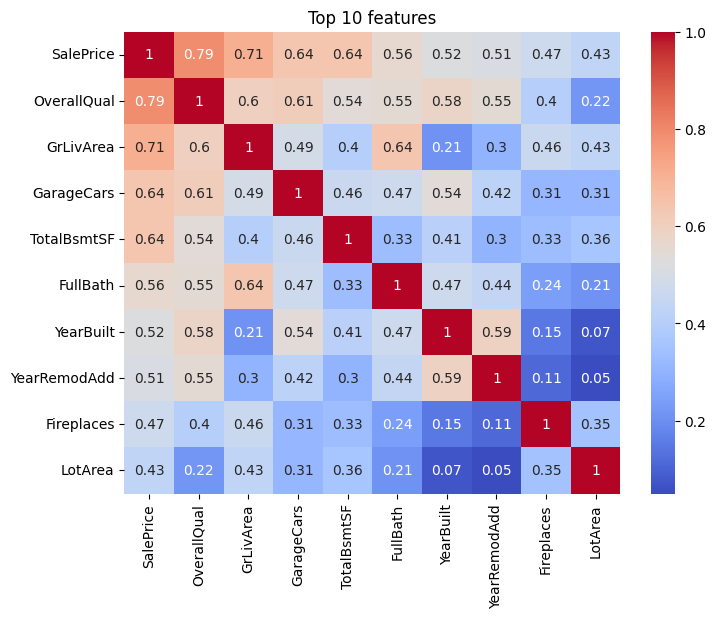

In [13]:
data_numeric=data.select_dtypes(include=['int64','float64'])
corr_matrix = data_numeric.corr()
top_10_largest=corr_matrix[target_name].sort_values(ascending=False).head(10).index
plt.figure(figsize=(8,6))
top_corr_matrix=np.round(data_numeric[top_10_largest].corr(),2)
sns.heatmap(top_corr_matrix,annot=True,cmap='coolwarm',fmt='g')
plt.title('Top 10 features')
plt.show()

## **The relationship of Living Area, Quality and SalePrice**

Linear Growth with Multipliers: There is a strong, positive linear trend between living area and sale price. However, the color gradient reveals that high OverallQual acts as a pricing multiplier, lifting the price ceiling significantly for houses of the same size.

Outlier Detection: The plot clearly isolates extreme outliers (e.g., massive houses over 4,000 sq.ft but with unusually low prices), which provides a strong justification for data cleaning strategies before model training.

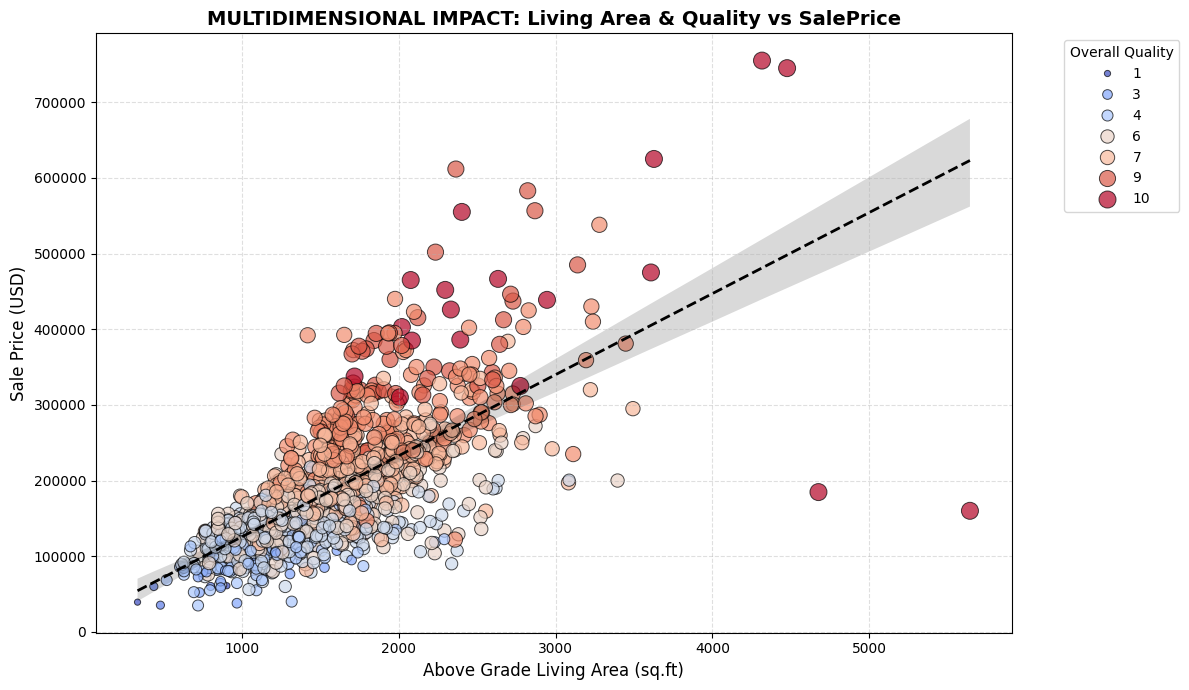

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df, 
    x='GrLivArea', 
    y='SalePrice', 
    hue='OverallQual', 
    palette='coolwarm', 
    size='OverallQual',
    sizes=(20, 150),
    alpha=0.7,
    edgecolor='k'
)

sns.regplot(
    data=df, 
    x='GrLivArea', 
    y='SalePrice', 
    scatter=False, 
    color='black', 
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

plt.title('MULTIDIMENSIONAL IMPACT: Living Area & Quality vs SalePrice', fontsize=14, fontweight='bold')
plt.xlabel('Above Grade Living Area (sq.ft)', fontsize=12)
plt.ylabel('Sale Price (USD)', fontsize=12)
plt.legend(title='Overall Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('EDA_Multidimensional_Scatter.png', dpi=300)
plt.show()

## **Sale Price Distribution By Location**

Location Premium: There is a severe price disparity across different neighborhoods. Premium areas like 'NoRidge' and 'NridgHt' not only boast the highest median prices but also exhibit the widest price variance, catering to the luxury segment.

Budget Clusters: Neighborhoods on the far right (e.g., 'MeadowV', 'IDOTRR') form a tightly clustered budget segment with very low variance, indicating highly standardized, affordable housing with strict price ceilings.

C:\Users\LOQ\AppData\Local\Temp\ipykernel_13620\4275080814.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


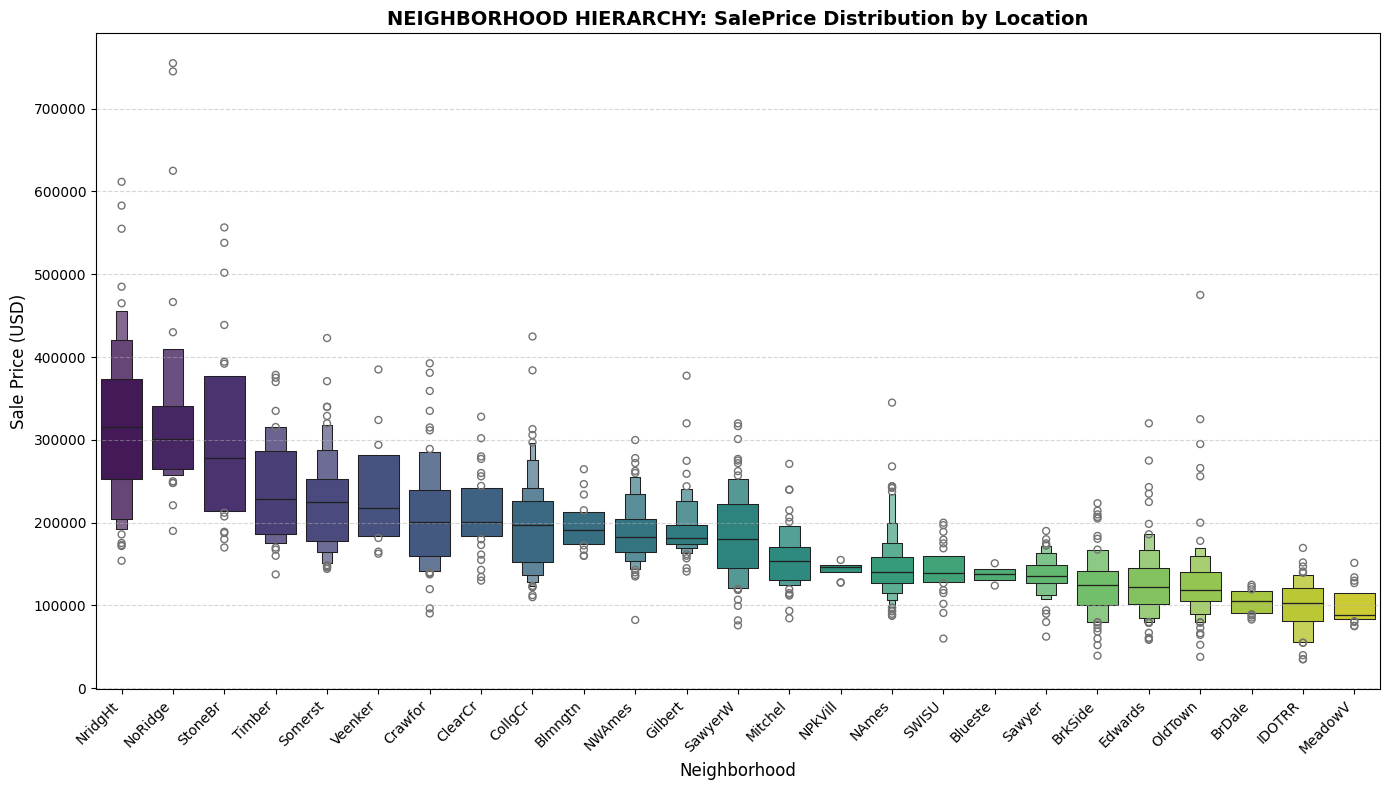

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sorted_neighborhoods = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 8))
sns.boxenplot(
    data=df, 
    x='Neighborhood', 
    y='SalePrice', 
    order=sorted_neighborhoods,
    palette='viridis'
)

plt.title('NEIGHBORHOOD HIERARCHY: SalePrice Distribution by Location', fontsize=14, fontweight='bold')
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Sale Price (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('EDA_Neighborhood_Boxen.png', dpi=300)
plt.show()

## **The Distribution of SalePrice Based On Central Air**

Density Shift: The distribution curve for houses with Central Air (Y) is substantially shifted to the right compared to houses without it (N).

Market Standard: The sharp, narrow peak of the 'N' curve indicates that lack of central air is strictly associated with low-tier, budget properties. Meanwhile, the 'Y' curve spans a much wider range, showing it is a baseline requirement for mid-to-high-end properties.

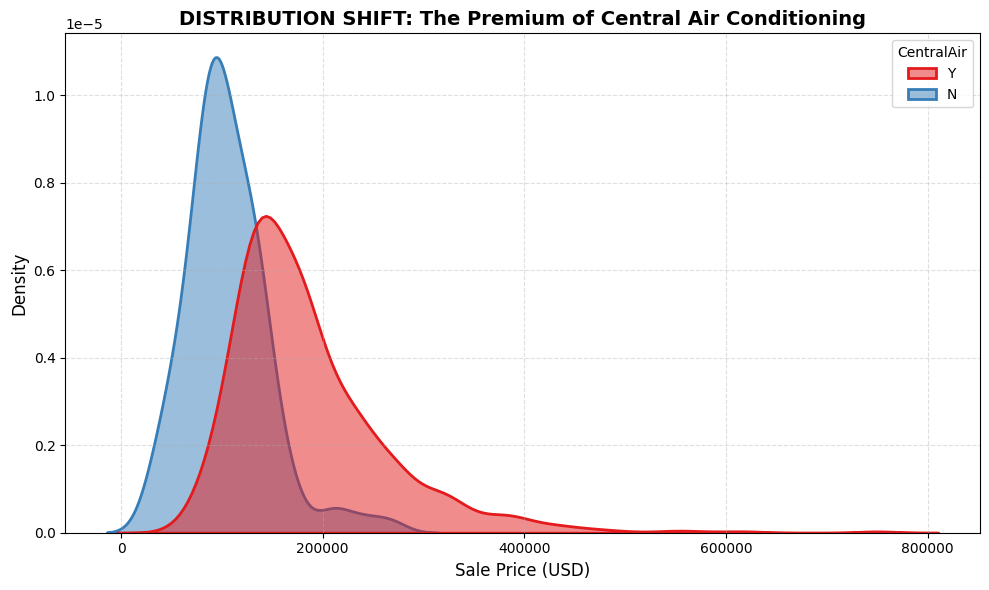

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df, 
    x='SalePrice', 
    hue='CentralAir', 
    fill=True, 
    common_norm=False, 
    palette='Set1', 
    alpha=0.5, 
    linewidth=2
)

plt.title('DISTRIBUTION SHIFT: The Premium of Central Air Conditioning', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price (USD)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('EDA_KDE_CentralAir.png', dpi=300)
plt.show()